# True Parameters at 1 PA Model

```python

m1 = 1e6
m2 = 1e4
a = -0.9 # 0.95
p0 = 42.0
e0 = 5.00000000e-01
xI0 = 1.0
dist = 5.0
qS = 1.04719755e+00
phiS = 7.85398163e-01
qK = 6.28318531e-01

phiK = 5.23598776e-01
Phi_phi0 = 0.1
Phi_theta0 =0.2
Phi_r0 = 0.3

dt = 10.0
T = 1.0

chi2 = 9.50000000e-01

dev_0_p=0.0
dev_0_e=0.0
dev_1_p=0.0
dev_1_e=0.0
dev_2_p=0.0
dev_2_e=0.0
evolve_1PA = False
evolve_primary = False
evolve_2PA = False
deviation_included=True

best_fit = [ 1.38248765e+01,9.98089433e+03,-8.93155110e-01,4.22413106e+01,5.00088445e-01,1.61598675e+00,2.00931361e+00,3.98289416e-01,4.14110626e-01]

# logm1_, m2_, a_, p0_, e0_,qS_,phiS_,Phi_phi0_,Phi_r0_,dev0p_,dev0e_ = params[i]

In [1]:
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt
from scipy.stats import chi2


from itertools import product
import os
import h5py
from tqdm import tqdm
import pandas as pd

#few utils
from few.utils.utility import get_p_at_t
from few.utils.constants import MTSUN_SI
from few.utils.geodesic import get_fundamental_frequencies
#few trajectory
from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode.flux import SuperKludgeFlux
#few waveform
from few.waveform import FastKerrEccentricEquatorialFlux, GenerateEMRIWaveform
from few.waveform.waveform import SuperKludgeWaveform
from few.utils.constants import YRSID_SI

#sef imports
from stableemrifisher.fisher import StableEMRIFisher
from stableemrifisher.utils import generate_PSD, padding, inner_product
from stableemrifisher.fisher.derivatives import derivative
from stableemrifisher.fisher.stablederivative import StableEMRIDerivative
from stableemrifisher.noise import sensitivity_LWA

#lisa-on-gpu import
from fastlisaresponse import ResponseWrapper  # Response function 

#LISAanalysistools imports
from lisatools.detector import ESAOrbits, EqualArmlengthOrbits #ESAOrbits correspond to esa-trailing-orbits.h5, EqualArmlengthOrbits are equalarmlength-orbits.h5
from lisatools.sensitivity import get_sensitivity, A1TDISens, E1TDISens, T1TDISens
from lisatools.sensitivity import get_sensitivity,CornishLISASens

use_gpu = True
from parismc.sampler import SamplerConfig
from parismc.sampler import Sampler

from smt.sampling_methods import LHS

if not use_gpu:
    
    import few
    
    #tune few configuration
    cfg_set = few.get_config_setter(reset=True)
    
    cfg_set.enable_backends("cpu")
    cfg_set.set_log_level("info");
else:
    pass #let the backend decide for itself

startup


In [2]:
#waveform class setup
waveform_class = SuperKludgeWaveform
max_step_days = 10.0 #max trajectory step size in days
inspiral_kwargs = {
    "err":1e-11, #default = 1e-11
    "max_step_size":max_step_days*24*60*60, #in seconds
}
sum_kwargs = {
    "pad_output": True, # True if expecting waveforms smaller than LISA observation window.
}

waveform_class_kwargs = dict(inspiral_kwargs=inspiral_kwargs,
                              mode_selector_kwargs=dict(mode_selection_threshold=1e-5),
                              sum_kwargs=sum_kwargs,
                              use_gpu=use_gpu)

waveform_generator = GenerateEMRIWaveform
waveform_generator_kwargs = dict(return_list=False)


In [3]:
if(use_gpu):
    xp=cp
else:
    xp=np

best_fit = [ 1.38248765e+01,9.98089433e+03,-8.93155110e-01,4.22413106e+01,
            5.00088445e-01,1.61598675e+00,2.00931361e+00,3.98289416e-01,4.14110626e-01]
#logm1_, m2_, a_, p0_, e0_,qS_,phiS_,Phi_phi0_,Phi_r0_,dev0p_,dev0e_ = params[i]

logm1 = best_fit[0]
m1= np.exp(logm1)
m2 = best_fit[1]
a = best_fit[2]
p0= best_fit[3]
e0 = best_fit[4]
xI0 = 1.0
dist = 5.0
qS = best_fit[5]
phiS = best_fit[6]
qK = 6.28318531e-01 
phiK =  5.23598776e-01
Phi_phi0 = best_fit[7]
Phi_theta0 = 0.2
Phi_r0 = best_fit[8]

dt = 10.0
T = 1.0

chi2 = 9.50000000e-01

dev_0_p=0.0
dev_0_e=0.0
dev_1_p=0.0
dev_1_e=0.0
dev_2_p=0.0
dev_2_e=0.0
evolve_1PA = False
evolve_primary = False
evolve_2PA = False
deviation_included=True


print(use_gpu)

pars_list_com = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0,\
             chi2,evolve_1PA,evolve_primary,evolve_2PA,deviation_included,dev_0_p,dev_0_e,dev_1_p,dev_1_e,dev_2_p,dev_2_e]

add_param_args={"chi2":chi2,"evolve_1PA":evolve_1PA,"evolve_primary":evolve_primary,"evolve_2PA":evolve_2PA,"deviation_included":deviation_included,"dev0p":dev_0_p,
"dev0e":dev_0_e,"dev1p":dev_1_p,"dev1e":dev_1_e,"dev2p":dev_2_p,"dev2e":dev_2_e}

param_names = ['m1','m2','a','p0','e0','qS','phiS','Phi_phi0','Phi_r0']
add_args = [chi2, evolve_1PA, evolve_primary, evolve_2PA,deviation_included,dev_0_p,dev_0_e,dev_1_p,dev_1_e,dev_2_p,dev_2_e]

emri_kwargs = {"T":T, "dt":dt}

param_names_com = ['m1','m2','a','p0','e0','xI0','dist','qS','phiS','qK','phiK','Phi_phi0','Phi_theta0','Phi_r0',"chi2",
               "evolve_1PA","evolve_primary","evolve_2PA","deviation_included","dev0p","dev0e","dev1p","dev1e","dev2p","dev2e"]

True


In [4]:
der_order = 8
Ndelta=16
sef = StableEMRIFisher(waveform_class=waveform_class, 
                       waveform_class_kwargs=waveform_class_kwargs,
                       waveform_generator=waveform_generator,
                       waveform_generator_kwargs=waveform_generator_kwargs,
                       stats_for_nerds = True, use_gpu = use_gpu,
                       deriv_type='stable',
                       noise_model=get_sensitivity,
                       noise_kwargs={'sens_fn':CornishLISASens,'return_type':'PSD'},
                       channels=["A","E"],
                       T = T, dt = dt,
                       stability_plot = False,
                       der_order = der_order, Ndelta = Ndelta,
                       plunge_check=True, return_derivatives=False
                       )
                   

SNR = sef.SNRcalc_SEF(*pars_list_com,**emri_kwargs,use_gpu=use_gpu)
print("SNR: ", SNR)

waveform shape: (2, 3155815)
wave ndim: 2
Computing SNR for parameters: (np.float64(1009409.9397234899), 9980.89433, -0.89315511, 42.2413106, 0.500088445, 1.0, 5.0, 1.61598675, 2.00931361, 0.628318531, 0.523598776, 0.398289416, 0.2, 0.414110626, 0.95, False, False, False, True, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0)
SNR:  9.037376352590341


Body is not plunging, Fisher should be stable.
waveform shape: (2, 3155815)
wave ndim: 2
Computing SNR for parameters: (np.float64(1009409.9397234899), 9980.89433, -0.89315511, 42.2413106, 0.500088445, 1.0, 5.0, 1.61598675, 2.00931361, 0.628318531, 0.523598776, 0.398289416, 0.2, 0.414110626, 0.95, False, False, False, True, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0)
Waveform Generated. SNR: 9.037376352590341
The optimal source SNR is <= 20. The Fisher approximation may not be valid!
calculating stable deltas...
Gamma_ii for m1: 2.3784527299181986
Gamma_ii for m1: 2.3784527298962344
Gamma_ii for m1: 2.378452729856937
Gamma_ii for m1: 2.3784527298663103
Gamma_ii for m1: 2.3784527298707254
Gamma_ii for m1: 2.3784527296436373
Gamma_ii for m1: 2.378452730315419
Gamma_ii for m1: 2.378452730661695
Gamma_ii for m1: 2.378452730030642
Gamma_ii for m1: 2.37845272996596
Gamma_ii for m1: 2.378452733337498
Gamma_ii for m1: 2.37845273044176
Gamma_ii for m1: 2.37845273203521
Gamma_ii for m1: 2.3784528582768543
Gam

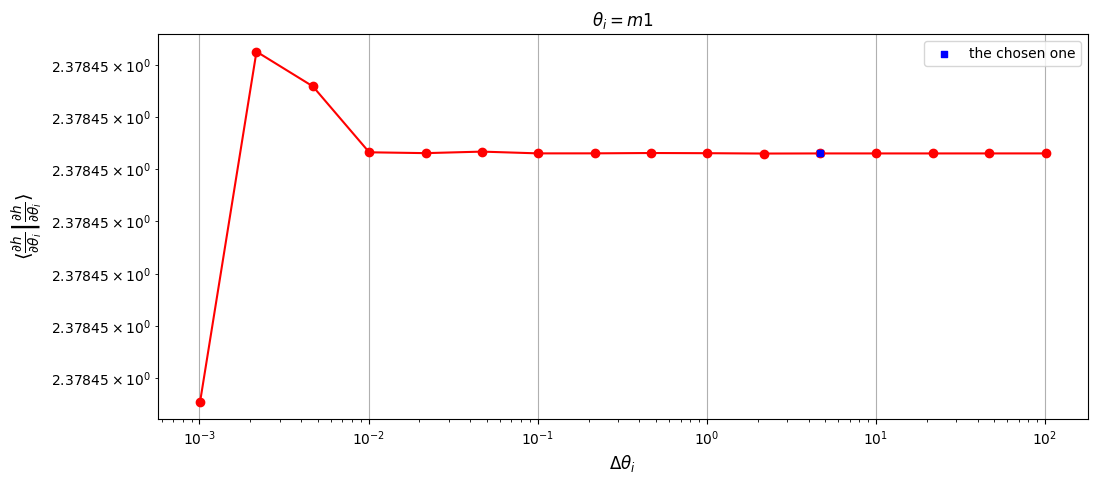

Gamma_ii for m2: 2452.0849116249406
Gamma_ii for m2: 2452.084911605383
Gamma_ii for m2: 2452.084911590109
Gamma_ii for m2: 2452.084911491339
Gamma_ii for m2: 2452.084911529141
Gamma_ii for m2: 2452.0849114278435
Gamma_ii for m2: 2452.084913748112
Gamma_ii for m2: 2452.084907308649
Gamma_ii for m2: 2452.0849001642846
Gamma_ii for m2: 2452.0849122393847
Gamma_ii for m2: 2452.084906633023
Gamma_ii for m2: 2452.0849155343494
Gamma_ii for m2: 2452.0848738560676
Gamma_ii for m2: 2452.084835524673
Gamma_ii for m2: 2452.084543893924
Gamma_ii for m2: 2452.086016545754
[np.float64(7.975977493422343e-12), np.float64(6.2288215232804335e-12), np.float64(4.028009578908381e-11), np.float64(1.5416365724837884e-11), np.float64(4.131084548580325e-11), np.float64(9.46243056003229e-10), np.float64(2.6261174850461255e-09), np.float64(2.9135876125444497e-09), np.float64(4.924421691185272e-09), np.float64(2.2863652866119267e-09), np.float64(3.6301053251732527e-09), np.float64(1.699707961839418e-08), np.float

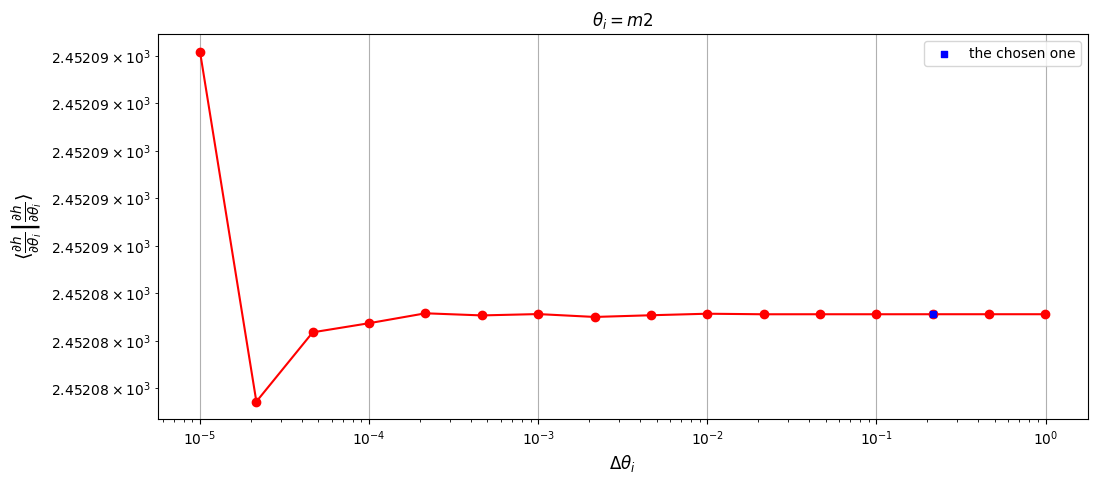

Gamma_ii for a: 1390718978.0420377
Gamma_ii for a: 1390728060.07179
Gamma_ii for a: 1390697908.2544575
Gamma_ii for a: 1390672999.778496
Gamma_ii for a: 1390846024.4379532
Gamma_ii for a: 1391144861.0262048
Gamma_ii for a: 1390363184.2354193
Gamma_ii for a: 1389642854.7498446
Gamma_ii for a: 1393217741.2586575
Gamma_ii for a: 1387874357.034127
Gamma_ii for a: 1378427982.031691
Gamma_ii for a: 1384059285.953719
Gamma_ii for a: 1404967957.0635364
Gamma_ii for a: 1508188032.4832497
Gamma_ii for a: 1906977890.7990944
Gamma_ii for a: 1825032834.5788772
[np.float64(6.530413826399438e-06), np.float64(2.1681069018325775e-05), np.float64(1.7911094819137312e-05), np.float64(0.00012440245463341402), np.float64(0.00021481342211273968), np.float64(0.0005622105070448959), np.float64(0.0005183558373380705), np.float64(0.0025659208915781457), np.float64(0.0038500489597265955), np.float64(0.0068530058338722435), np.float64(0.004068686926331658), np.float64(0.01488195585151837), np.float64(0.06843979211

/home/svu/e1583490/scratch/StableEMRIFisher/stableemrifisher/plot.py:163: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  plt.scatter(
/home/svu/e1583490/anaconda3/envs/few_gpu/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  fig.canvas.print_figure(bytes_io, **kw)


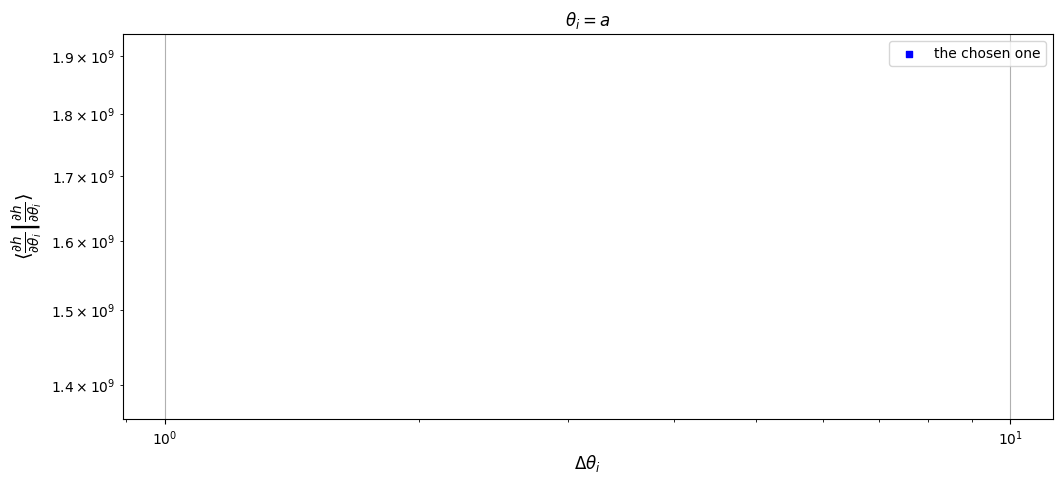

Gamma_ii for p0: 4855547662.541635
Gamma_ii for p0: 4855547686.103947
Gamma_ii for p0: 4855547680.161365
Gamma_ii for p0: 4855547673.639209
Gamma_ii for p0: 4855547965.74889
Gamma_ii for p0: 4855547086.874682
Gamma_ii for p0: 4855547399.501442
Gamma_ii for p0: 4855545190.3819275
Gamma_ii for p0: 4855553580.532782
Gamma_ii for p0: 4855544440.615678
Gamma_ii for p0: 4855524022.183425
Gamma_ii for p0: 4855529495.202333
Gamma_ii for p0: 4855430991.381436
Gamma_ii for p0: 4855650030.917302
Gamma_ii for p0: 4855538890.654351
Gamma_ii for p0: 4856732442.659899
[np.float64(4.8526579593878695e-09), np.float64(1.2238747350195187e-09), np.float64(1.3432379208482628e-09), np.float64(6.015998259928679e-08), np.float64(1.8100415705418243e-07), np.float64(6.438548196671165e-08), np.float64(4.5496837694791737e-07), np.float64(1.7279493913421294e-06), np.float64(1.8823670992100864e-06), np.float64(4.2051964236194185e-06), np.float64(1.1271724152656202e-06), np.float64(2.028734855298122e-05), np.float64

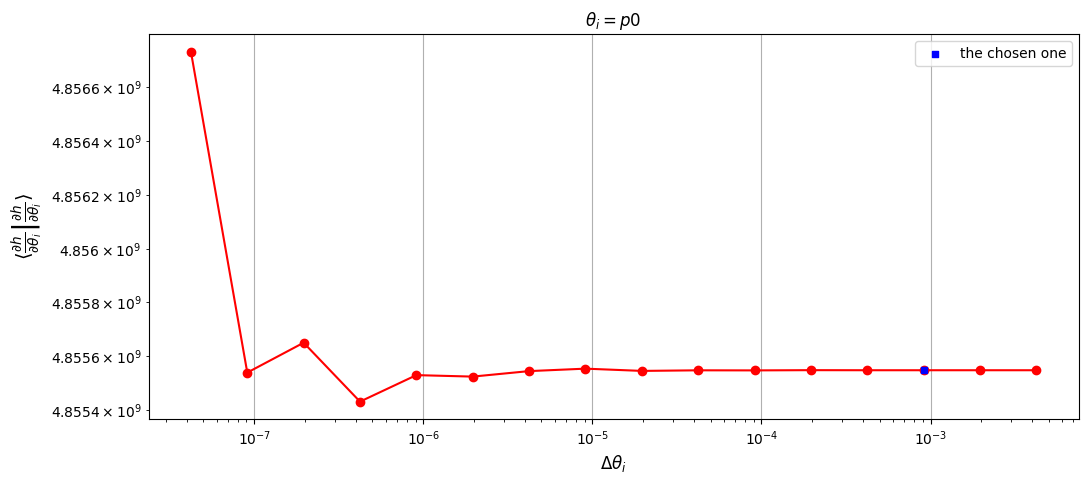

Gamma_ii for e0: 1018348110235.0582
Gamma_ii for e0: 1018348134523.4463
Gamma_ii for e0: 1018348071054.0093
Gamma_ii for e0: 1018348046380.4073
Gamma_ii for e0: 1018348214198.6815
Gamma_ii for e0: 1018349141685.7076
Gamma_ii for e0: 1018348037678.5645
Gamma_ii for e0: 1018346204313.8555
Gamma_ii for e0: 1018345253965.2695
Gamma_ii for e0: 1018350592446.9712
Gamma_ii for e0: 1018350891782.2458
Gamma_ii for e0: 1018341332273.3313
Gamma_ii for e0: 1018492250877.81
Gamma_ii for e0: 1018429046898.9938
Gamma_ii for e0: 1017493954451.5385
Gamma_ii for e0: 1017856939547.845
[np.float64(2.3850770908408067e-08), np.float64(6.232587738495611e-08), np.float64(2.4229046264104118e-08), np.float64(1.647945877746492e-07), np.float64(9.107750850437664e-07), np.float64(1.0841157466215395e-06), np.float64(1.800335388120453e-06), np.float64(9.332282762029855e-07), np.float64(5.2422827081903505e-06), np.float64(2.939411916597114e-07), np.float64(9.387332725865367e-06), np.float64(0.00014817845138113446), n

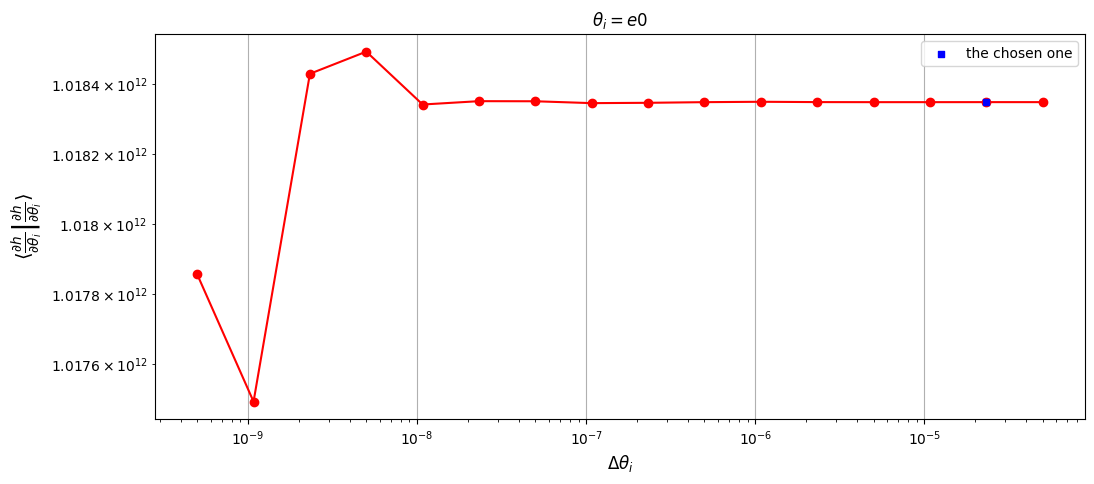

Gamma_ii for qS: 235.25695807554263
Gamma_ii for qS: 235.25692485181088
Gamma_ii for qS: 235.25692477322715
Gamma_ii for qS: 235.25692477305438
Gamma_ii for qS: 235.25692477304761
Gamma_ii for qS: 235.25692477305222
Gamma_ii for qS: 235.25692477313257
Gamma_ii for qS: 235.25692477300322
Gamma_ii for qS: 235.25692477353877
Gamma_ii for qS: 235.25692477316863
Gamma_ii for qS: 235.25692477316127
Gamma_ii for qS: 235.2569247717244
Gamma_ii for qS: 235.25692477229222
Gamma_ii for qS: 235.25692476532947
Gamma_ii for qS: 235.25692475777038
Gamma_ii for qS: 235.25692482805235
[np.float64(1.4122318298980744e-07), np.float64(3.340336293707527e-10), np.float64(7.344122677540634e-13), np.float64(2.875310408380854e-14), np.float64(1.957144059486089e-14), np.float64(3.415337195163756e-13), np.float64(5.498125070816696e-13), np.float64(2.2764484884456855e-12), np.float64(1.573326363374983e-12), np.float64(3.1290142679423587e-14), np.float64(6.107618390609733e-12), np.float64(2.4135693839839135e-12), 

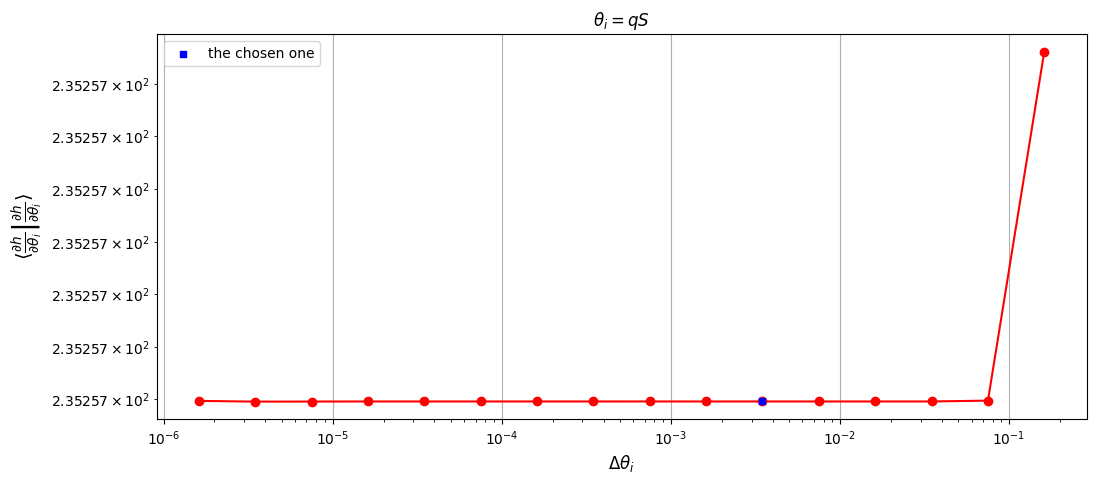

Gamma_ii for phiS: 122.93416312504371
Gamma_ii for phiS: 122.93407441530394
Gamma_ii for phiS: 122.9340741942165
Gamma_ii for phiS: 122.93407419372863
Gamma_ii for phiS: 122.93407419373001
Gamma_ii for phiS: 122.93407419373013
Gamma_ii for phiS: 122.93407419370301
Gamma_ii for phiS: 122.93407419369987
Gamma_ii for phiS: 122.93407419367449
Gamma_ii for phiS: 122.93407419388622
Gamma_ii for phiS: 122.93407419305447
Gamma_ii for phiS: 122.93407419300436
Gamma_ii for phiS: 122.93407419629999
Gamma_ii for phiS: 122.93407418938061
Gamma_ii for phiS: 122.93407418637368
Gamma_ii for phiS: 122.93407418071676
[np.float64(7.216041621717934e-07), np.float64(1.7984227257969626e-09), np.float64(3.968573045572164e-12), np.float64(1.121294414437376e-14), np.float64(9.247788985050516e-16), np.float64(2.2055976729350343e-13), np.float64(2.5547017071208337e-14), np.float64(2.064568890913462e-13), np.float64(1.7222851011011585e-12), np.float64(6.765798018862455e-12), np.float64(4.0759629951850776e-13), np

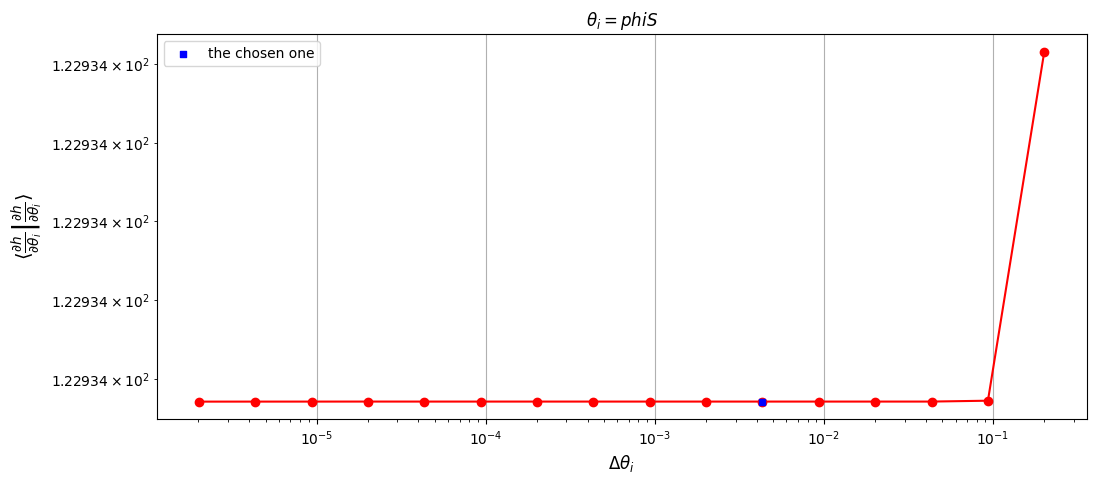

stable deltas: {'m1': 4.6852659047583, 'm2': 0.2150318498209454, 'a': -4.145658785260196e-05, 'p0': 0.0009100614490905154, 'e0': 2.321204942130781e-05, 'qS': 0.0034815379128318833, 'phiS': 0.004328934944537197, 'Phi_phi0': 0.0, 'Phi_r0': 0.0}
Time taken to compute stable deltas is 174.6080026626587 seconds
calculating Fisher matrix...
Finished derivatives
Calculated Fisher is *atleast* positive-definite.
Time taken to compute FM is 12.540781497955322 seconds


In [5]:
param_names = ['m1','m2','a','p0','e0','qS','phiS','Phi_phi0','Phi_r0']
pars_list = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]

param_dict = {
    'm1': m1,
    'm2': m2,
    'a': a,
    'p0': p0,
    'e0': e0,
    'xI0': xI0,
    'dist': dist,
    'qS': qS,
    'phiS': phiS,
    'qK': qK,
    'phiK': phiK,
    'Phi_phi0': Phi_phi0,
    'Phi_theta0': Phi_theta0,
    'Phi_r0': Phi_r0
}


Fisher = sef(wave_params = param_dict,param_names=param_names, add_param_args=add_param_args,
            live_dangerously = False, stability_plot = True,der_order = der_order, Ndelta = Ndelta,return_derivatives=True
            )


In [19]:
def logmasstransform(Fisher, m1, index_of_m1 = 0):    
    J = np.eye(len(Fisher))
    J[index_of_m1,index_of_m1] = m1
    
    return J.T@Fisher@J
fisher_=logmasstransform(Fisher[-1], m1, index_of_m1 = 0)
cov=np.linalg.inv(fisher_)
std= np.sqrt(np.diag(cov))


In [20]:
pd.DataFrame(fisher_)

,0,1,2,3,4,5,6,7,8
0,2.423426e+12,-7.625592e+07,5.659826e+10,1.084157e+11,1.534795e+12,44471.500798,-50519.438790,-2.818643e+07,-1.788438e+07
1,-7.625592e+07,2.452085e+03,-1.837821e+06,-3.428114e+06,-4.674619e+07,-1.526130,1.356212,8.407865e+02,4.717338e+02
2,5.659826e+10,-1.837821e+06,1.390728e+09,2.550956e+09,3.419383e+10,1196.067521,-955.381860,-6.223875e+05,-3.094498e+05
3,1.084157e+11,-3.428114e+06,2.550956e+09,4.855548e+09,6.817220e+10,2031.210077,-2189.946554,-1.247966e+06,-7.696980e+05
4,1.534795e+12,-4.674619e+07,3.419383e+10,6.817220e+10,1.018348e+12,25094.035299,-38688.782120,-1.931361e+07,-1.420653e+07
5,4.447150e+04,-1.526130e+00,1.196068e+03,2.031210e+03,2.509404e+04,235.256925,169.202677,-3.847798e-01,-4.925431e-02
6,-5.051944e+04,1.356212e+00,-9.553819e+02,-2.189947e+03,-3.868878e+04,169.202677,122.934074,9.432000e-01,8.651852e-01
7,-2.818643e+07,8.407865e+02,-6.223875e+05,-1.247966e+06,-1.931361e+07,-0.384780,0.943200,4.175053e+02,3.074207e+02
8,-1.788438e+07,4.717338e+02,-3.094498e+05,-7.696980e+05,-1.420653e+07,-0.049254,0.865185,3.074207e+02,4.418885e+02


In [21]:
from scipy.stats import chi2
def plot_confidence_ellipse(ax, mean, cov, i, j, levels=[0.90, 0.99]):

    # Extract 2x2 sub-covariance
    cov2 = cov[np.ix_([i, j], [i, j])]
    mean2 = mean[[i, j]]
    
    # Eigen decomposition
    eigvals, eigvecs = np.linalg.eigh(cov2)
    order = np.argsort(eigvals)[::-1]
    eigvals = eigvals[order]
    eigvecs = eigvecs[:, order]

    theta = np.linspace(0, 2*np.pi, 400)

    for p in levels:
        chi2_val = chi2.ppf(p, df=2)
        r1 = np.sqrt(eigvals[0] * chi2_val)
        r2 = np.sqrt(eigvals[1] * chi2_val)
        
        ellipse = np.vstack([r1*np.cos(theta), r2*np.sin(theta)])
        ellipse = eigvecs @ ellipse + mean2[:, None]

        ax.plot(ellipse[0], ellipse[1], label=f"{int(p*100)}%", lw=1)


# --------------------------------------------------------------------
# Main triangle plot function (WITH LEGEND)
# --------------------------------------------------------------------
def triangle_plot(best_fit, cov, param_truth=None, labels=None,levels=[0.90, 0.99]):
    D = len(best_fit)
    if labels is None:
        labels = [f"p{i}" for i in range(D)]

    fig, axes = plt.subplots(D, D, figsize=(2.2*D, 2.2*D))
    
    legend_ax = axes[-1, -1]  # bottom-right panel for legend only
    legend_handles = []       # store handles for legend

    for i in range(D):
        for j in range(D):

            ax = axes[i, j]

            if i < j:
                ax.axis("off")
                continue

            # ==========================
            # Diagonal panels
            # ==========================
            if i == j:
                ax.axis("off")
                continue
                sigma = np.sqrt(cov[i, i])
                x = np.linspace(best_fit[i] - 4*sigma,
                                best_fit[i] + 4*sigma, 300)
                y = np.exp(-0.5*((x - best_fit[i])/sigma)**2)

                ax.plot(x, y, lw=1.5)

                if param_truth is not None:
                    line_truth = ax.axvline(param_truth[i], color='red', linestyle='--', lw=1)

                ax.set_yticks([])
                ax.set_xlabel(labels[i])

            # ==========================
            # Off-diagonal panels
            # ==========================
            else:
                # Ellipses
                plot_confidence_ellipse(ax, best_fit, cov, j, i,levels=levels)

                # Best-fit point
                bestfit_handle = ax.scatter(best_fit[j], best_fit[i],
                                            color="black", s=12, label="Best-fit")

                # Truth point
                if param_truth is not None:
                    truth_handle = ax.scatter(param_truth[j], param_truth[i],
                                              color="red", marker="x", s=30,
                                              label="Param truth")

                ax.set_xlabel(labels[j])
                ax.set_ylabel(labels[i])

                # Collect handles only once (avoid duplicates)
                if i == D - 1 and j == 0:
                    # ellipse handles (match levels dynamically)
                    level_labels = {f"{int(p*100)}%" for p in levels}
                    for item in ax.get_lines():
                        if item.get_label() in level_labels:
                            legend_handles.append(item)
                
                    legend_handles.append(bestfit_handle)
                    if param_truth is not None:
                        legend_handles.append(truth_handle)

    # Add the legend to bottom-right subplot
    legend_ax.legend(handles=legend_handles, loc="upper right", fontsize=9)
    legend_ax.axis("off")  # hide this subplot except for legend

    plt.tight_layout()
    plt.show()


In [22]:
m1_true = 1e6
m2_true = 1e4
a_true = -0.9 
e0_true = 5.00000000e-01
xI0_true = 1.0
dist_true = 5
qS_true = 1.04719755e+00
phiS_true = 7.85398163e-01
qK_true = 6.28318531e-01
phiK_true = 5.23598776e-01
Phi_phi0_true = 0.1
Phi_theta0_true = 0.2
Phi_r0_true = 0.3
p0_true= 42.0
dev_0_p_true=0.0
dev_0_e_true=0.0

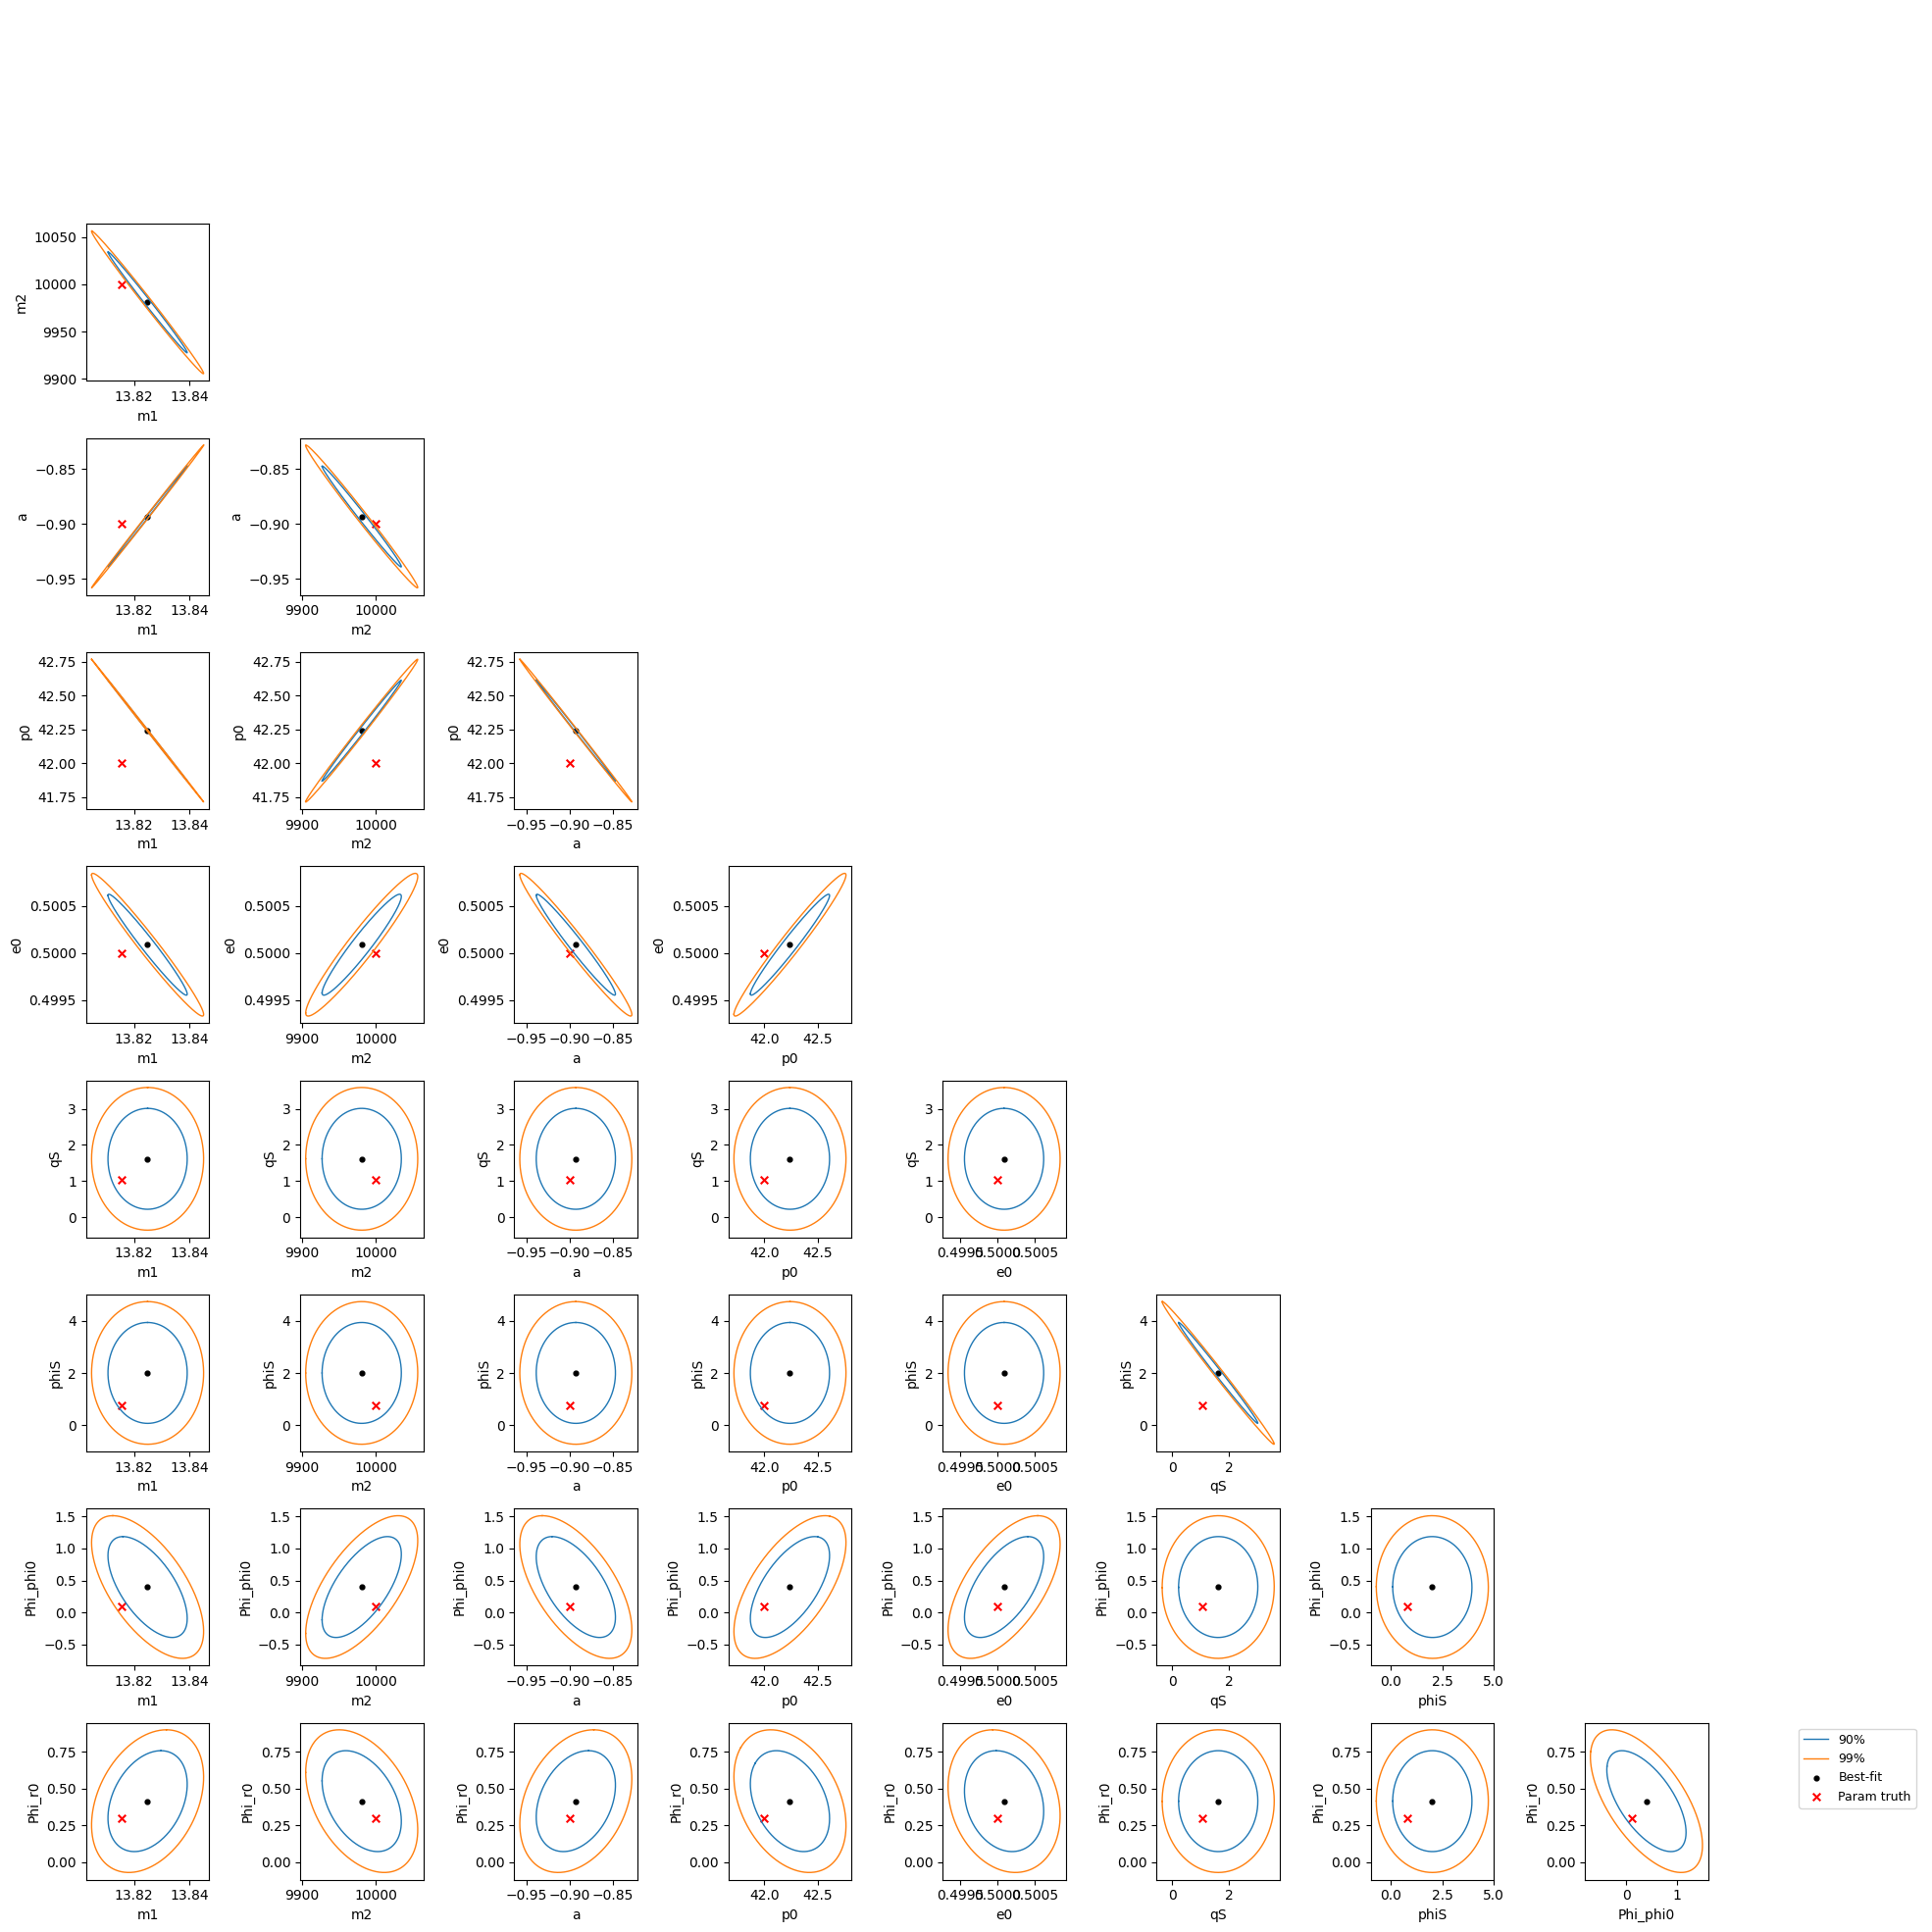

In [23]:
labels = param_names
params_truth_in = [np.log(m1_true), m2_true, a_true, p0_true, e0_true, qS_true, phiS_true, Phi_phi0_true, Phi_r0_true]
triangle_plot(np.array(best_fit), cov, np.array(params_truth_in), labels,levels=[0.90, 0.99])


In [24]:
# True waveform with 1PA order
m1_true = 1e6
m2_true = 1e4
a_true = -0.9 
e0_true = 5.00000000e-01
xI0_true = 1.0
dist_true = 5
qS_true = 1.04719755e+00
phiS_true = 7.85398163e-01
qK_true = 6.28318531e-01
phiK_true = 6.28318531e-01
Phi_phi0_true = 0.1
Phi_theta0_true = 0.2
Phi_r0_true = 0.3
p0_true= 42.0
dev_0_p_true=0.0
dev_0_e_true=0.0

evolve_1PA_true = True
evolve_primary = False
evolve_2PA = False
deviation_included=True
chi2 = 9.50000000e-01

superkludge_wave = GenerateEMRIWaveform(SuperKludgeWaveform,\
                                    sum_kwargs=sum_kwargs,\
                                    return_list=True,
                                    mode_selector_kwargs=dict(mode_selection_threshold=1e-5),
                                    inspiral_kwargs=inspiral_kwargs,
                                    use_gpu=use_gpu)

add_args = [chi2, evolve_1PA_true, evolve_primary, evolve_2PA,deviation_included,dev_0_p_true,dev_0_e_true,0,0,0,0]
waveform_true = superkludge_wave(m1_true, m2_true, a_true, p0_true, e0_true, xI0_true, dist_true, qS_true, phiS_true, qK_true, phiK_true, Phi_phi0_true, Phi_theta0_true, Phi_r0_true, *add_args, dt=dt, T=T)
waveform_true= xp.asarray(waveform_true)
fisher_derivs = xp.array(Fisher[0])
fisher_exact = xp.array(Fisher[-1])


In [25]:
# baseline check - 0PA model at true parameters
evolve_1PA_approx = False
add_args = [chi2, evolve_1PA_approx, evolve_primary, evolve_2PA,deviation_included,dev_0_p_true,dev_0_e_true,dev_1_p,dev_1_e,dev_2_p,dev_2_e]
waveform_approx = superkludge_wave(m1_true, m2_true, a_true, p0_true, e0_true, xI0_true, dist_true, qS_true, phiS_true, qK_true, phiK_true, Phi_phi0_true, Phi_theta0_true, Phi_r0_true, *add_args, dt=dt, T=T)
waveform_approx= xp.asarray(waveform_approx)

In [26]:
# waveform at best fit parameters with 0PA calaculated during fisher calculation
waveform_best_fit=sef.waveform
waveform_best_fit= xp.asarray(waveform_best_fit)

# waveform analysis and p0 evolution 

In [27]:
from few.utils.utility import ( 
    get_mismatch, 
    get_m2_at_t, 
    get_p_at_t, 
    )

from few.utils.geodesic import (
    get_fundamental_frequencies,
    get_separatrix,
    get_kerr_geo_constants_of_motion,
    ELQ_to_pex,
    )
SK_traj = EMRIInspiral(func=SuperKludgeFlux)
#get_p_at_t may fail with SuperKludge, especially with lower eccentricities, so we use KerrEccEq to generate p0 
add_args = [chi2, evolve_1PA_true, evolve_primary, evolve_2PA,deviation_included,dev_0_p_true,dev_0_e_true,dev_1_p,dev_1_e,dev_2_p,dev_2_e]
p_sep = get_separatrix(a_true, e0_true, xI0_true)
p0_should = get_p_at_t(traj_module=SK_traj, t_out=0.5, traj_args=[m1_true, m2_true, a_true, e0_true, xI0_true, *add_args])
print('should take p0 around for for true waveform: ', p0_should+0.1)
print('separatrix p: ', p_sep)

should take p0 around for for true waveform:  35.888937507463716
separatrix p:  10.078971965107378


# P evolution is done considering true waveform (1PA)


[0.95, True, False, False, True, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


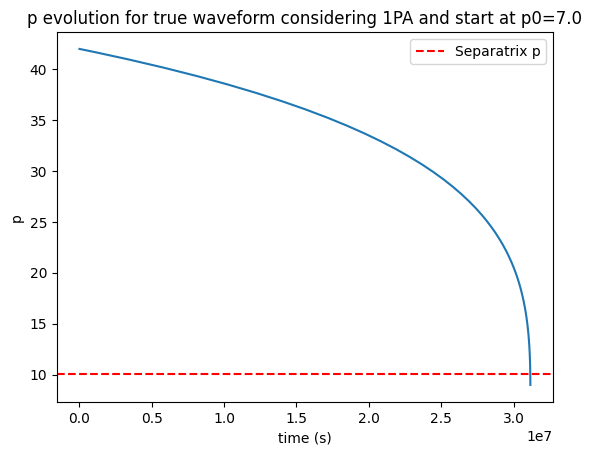

In [28]:
from scipy.interpolate import CubicSpline
add_args = [chi2, evolve_1PA_true, evolve_primary, evolve_2PA,deviation_included,dev_0_p_true,dev_0_e_true,dev_1_p,dev_1_e,dev_2_p,dev_2_e]
print(add_args) 
t_evol, p_evol, e_evol, x2_evol, pp2_evol, pt2_evol, pr2_evol, _, _ = SK_traj(m1_true, m2_true, a_true, p0_true, e0_true, xI0_true, *add_args,
                                               Phi_phi0=Phi_phi0_true, Phi_theta0=Phi_theta0_true, Phi_r0=Phi_r0_true, T=T, dt=dt)
p_evolution = CubicSpline(t_evol, p_evol)(t_evol)
plt.plot(t_evol, p_evolution)
plt.title('p evolution for true waveform considering 1PA and start at p0=7.0')
plt.xlabel('time (s)')
plt.ylabel('p')
plt.axhline(p_sep, color='red', linestyle='--', label='Separatrix p')
plt.legend()
plt.show()

# Waveform Visualization

# Overlap and mismatch

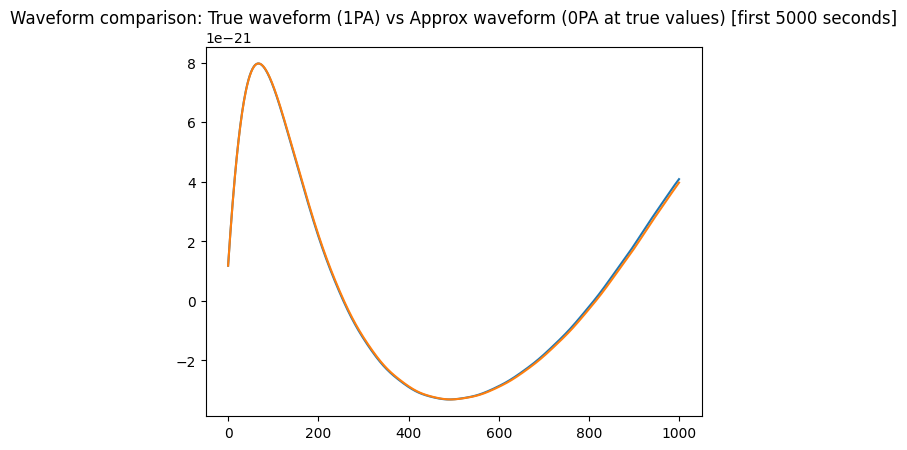

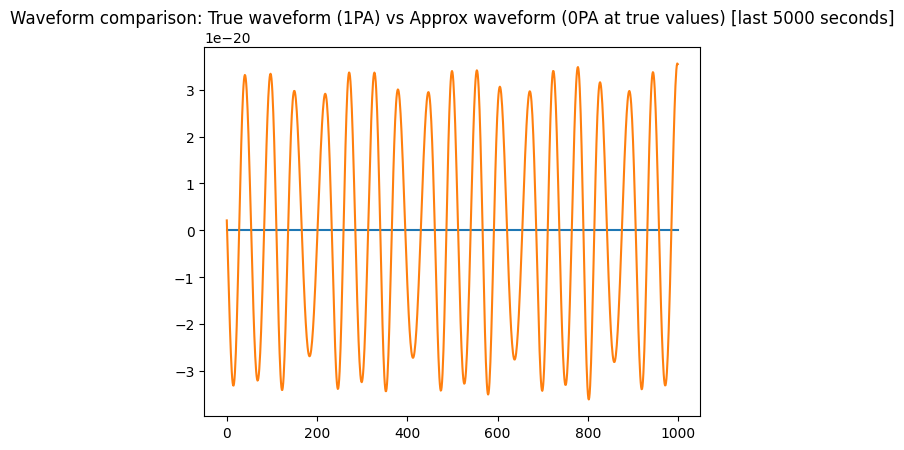

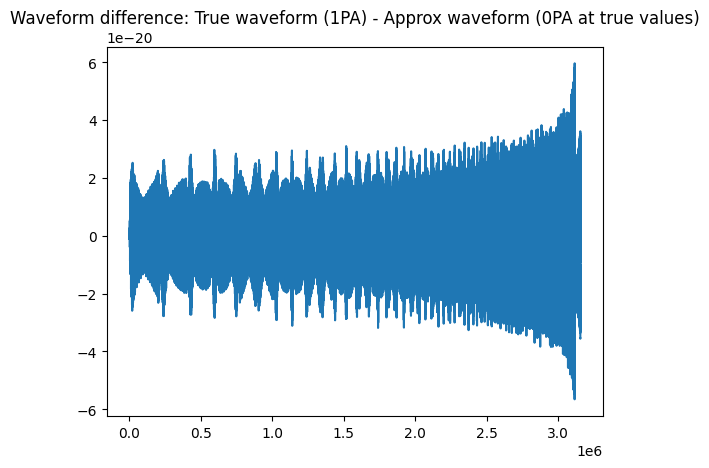

In [29]:
plt.plot(waveform_true[0][0:1000].get())
plt.plot(waveform_approx[0][0:1000].get())
plt.title('Waveform comparison: True waveform (1PA) vs Approx waveform (0PA at true values) [first 5000 seconds]')
plt.show()

plt.plot(waveform_true[0][-1000:].get())
plt.plot(waveform_approx[0][-1000:].get())
plt.title('Waveform comparison: True waveform (1PA) vs Approx waveform (0PA at true values) [last 5000 seconds]')
plt.show()
# waveform_approx
# waveform_best_fit
plt.plot((waveform_true[0]-waveform_approx[0]).get())
plt.title('Waveform difference: True waveform (1PA) - Approx waveform (0PA at true values)')
plt.show()

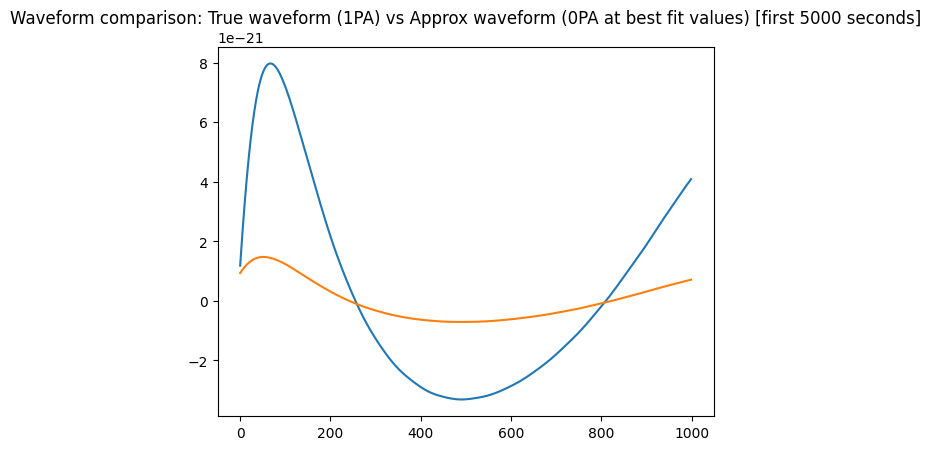

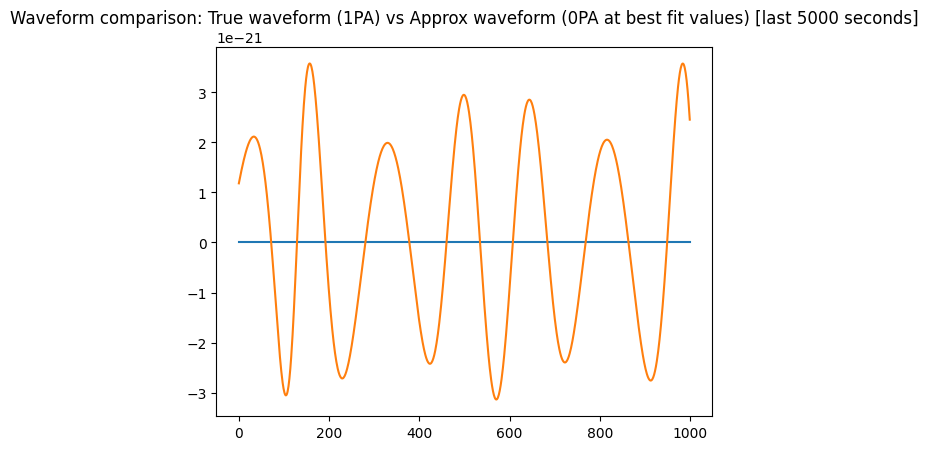

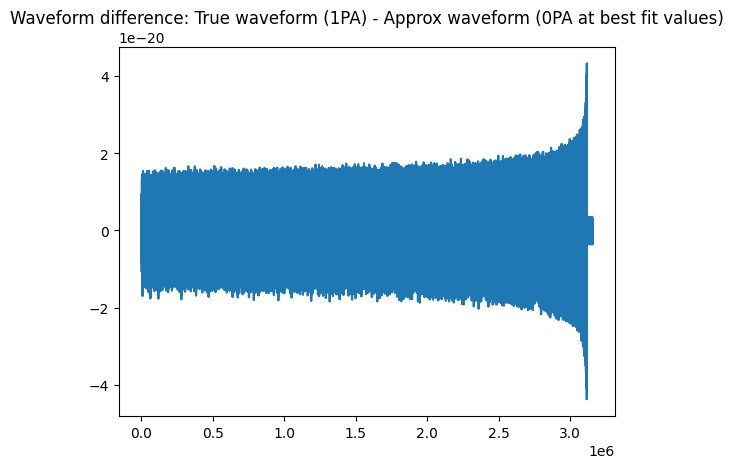

In [30]:
plt.plot(waveform_true[0][0:1000].get())
plt.plot(waveform_best_fit[0][0:1000].get())
plt.title('Waveform comparison: True waveform (1PA) vs Approx waveform (0PA at best fit values) [first 5000 seconds]')
plt.show()

plt.plot(waveform_true[0][-1000:].get())
plt.plot(waveform_best_fit[0][-1000:].get())
plt.title('Waveform comparison: True waveform (1PA) vs Approx waveform (0PA at best fit values) [last 5000 seconds]')
plt.show()
# waveform_approx
# waveform_best_fit
plt.plot((waveform_true[0]-waveform_best_fit[0]).get())
plt.title('Waveform difference: True waveform (1PA) - Approx waveform (0PA at best fit values)')
plt.show()

In [31]:
PSD=generate_PSD(waveform_true,dt,use_gpu=use_gpu,
                noise_PSD=get_sensitivity,
                noise_kwargs={'sens_fn':CornishLISASens,'return_type':'PSD'},
                channels=["A","E"])
diff_inner_bf=inner_product(waveform_best_fit,waveform_true,PSD,dt,use_gpu=use_gpu)
norm_true=np.sqrt(inner_product(waveform_true,waveform_true,PSD,dt,use_gpu=use_gpu))
norm_bf=np.sqrt(inner_product(waveform_best_fit,waveform_best_fit,PSD,dt,use_gpu=use_gpu))
overlap_bf=diff_inner_bf/((norm_true)*norm_bf)
print("overlap between best fit point and true waveform:", overlap_bf)
print("mismatch between best fit point and true waveform:", 1-overlap_bf)

norm_approx=np.sqrt(inner_product(waveform_approx,waveform_approx,PSD,dt,use_gpu=use_gpu))
diff_inner_approx=inner_product(waveform_approx,waveform_true,PSD,dt,use_gpu=use_gpu)
overlap_approx=diff_inner_approx/((norm_true)*norm_approx)
print("overlap between approximate waveform and true waveform (both at true points)", overlap_approx)
print("mismatch between approximate waveform and true waveform (both at true points):", 1-overlap_approx)

overlap between best fit point and true waveform: 0.00866711232390485
mismatch between best fit point and true waveform: 0.9913328876760952
overlap between approximate waveform and true waveform (both at true points) -0.007383755972039227
mismatch between approximate waveform and true waveform (both at true points): 1.0073837559720393


# Table true vs bias

In [32]:
best_fit

[13.8248765,
 9980.89433,
 -0.89315511,
 42.2413106,
 0.500088445,
 1.61598675,
 2.00931361,
 0.398289416,
 0.414110626]

In [33]:
import pandas as pd
best_fit[0] = np.exp(13.81561299)
truue_param=[m1_true,m2_true,a_true,p0_true,e0_true,qS_true,phiS_true,Phi_phi0_true,Phi_r0_true]
df = pd.DataFrame({'Best Fit': best_fit, 'True Param': truue_param}, index=param_names)
print(df)

              Best Fit      True Param
m1        1.000102e+06  1000000.000000
m2        9.980894e+03    10000.000000
a        -8.931551e-01       -0.900000
p0        4.224131e+01       42.000000
e0        5.000884e-01        0.500000
qS        1.615987e+00        1.047198
phiS      2.009314e+00        0.785398
Phi_phi0  3.982894e-01        0.100000
Phi_r0    4.141106e-01        0.300000


In [34]:
# #Orthoganal check between derivative and exact fisher matrices
# PSD=generate_PSD(waveform_true,dt,use_gpu=use_gpu,
#                 noise_PSD=get_sensitivity,
#                 noise_kwargs={'sens_fn':CornishLISASens,'return_type':'PSD'},
#                 channels=["A","E"])
# inner_val = []
# for i in range(fisher_derivs.shape[0]):
#     temp_deriv = inner_product(fisher_derivs[i],waveform_true-sef.waveform, PSD=PSD, dt=dt,use_gpu=use_gpu)
#     inner_val.append(temp_deriv)
